Librerias

In [1]:
import os, re, random, math, pickle, lmdb, time
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm # Librería para Vision Transformers

from sklearn.metrics import f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore") # <--- Esto silencia los warnings

Configuracion

In [2]:
# ==== 1. CONFIGURACIÓN E HIPERPARÁMETROS ====
import torch
import random
import numpy as np
import os
from pathlib import Path

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# --- RUTAS ACTUALIZADAS (Según tu entorno) ---
LMDB_DIR = r"D:\NUEVO\Dataset_Preprocesado"
LANDMARKS_DIR = r"D:\NUEVO\LandmarksCompletoFinal\npy_landmarks"
OUTDIR = r"C:\Users\Cesar\Desktop\Sign_Recognition\S2D_GCN_Model"
Path(OUTDIR).mkdir(parents=True, exist_ok=True)

# Hiperparámetros AJUSTADOS ANTI-OVERFITTING
NUM_FRAMES = 16
FRAME_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 40              # Más épocas porque aprender será más difícil ahora
LEARNING_RATE = 5e-5     # LR más bajo y fino
WEIGHT_DECAY = 0.1       # ¡Muy alto! Fuerza a los pesos a mantenerse simples
LABEL_SMOOTH = 0.2       # Ayuda a que no esté 100% seguro (reduce overconfidence)
PATIENCE = 10
DROPOUT = 0.6            # Apagamos el 60% de las neuronas aleatoriamente

# Configuración de Color (Según tu última prueba visual)
FORCE_COLOR_SWAP = True  # True = Convierte BGR a RGB

# Semilla
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything()

Device: cuda


Utilitarios

In [3]:
# ==== 2. UTILITARIOS (Parsing y Normalización Auto) ====
import unicodedata
import re

def _normalize_token(s: str) -> str:
    if not isinstance(s, str): return str(s)
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(c for c in s if not unicodedata.combining(c))
    s = s.replace(' ', '_')
    s = re.sub(r'[^a-zA-Z0-9_]', '_', s)
    s = re.sub(r'_+', '_', s).strip('_')
    return s

def _convert_muestra_to_code(muestra_str: str) -> str:
    """Convierte 'muestra_1' -> 'M01'"""
    try:
        parts = muestra_str.split('_')
        num = int(parts[-1])
        return f"M{num:02d}"
    except:
        return "M??"

def temporal_resample(arr, target_T=16):
    T = len(arr)
    if T == target_T: return arr
    if T == 0: return np.zeros((target_T, *arr.shape[1:])) if hasattr(arr, 'shape') else []
    indices = np.linspace(0, T-1, target_T).astype(int)
    if isinstance(arr, list): return [arr[i] for i in indices]
    return arr[indices]

def normalize_landmarks_automatic(lmk):
    """Normalización robusta usando Centroide y Ancho (Sin índices manuales)."""
    # 1. Centrar (Restar promedio)
    centroid = np.mean(lmk[:, :, :2], axis=1, keepdims=True)
    lmk[:, :, :2] = lmk[:, :, :2] - centroid
    
    # 2. Escalar (Dividir por ancho del bounding box)
    min_xy = np.min(lmk[:, :, :2], axis=1, keepdims=True)
    max_xy = np.max(lmk[:, :, :2], axis=1, keepdims=True)
    width = max_xy[:, :, 0] - min_xy[:, :, 0]
    width[width == 0] = 1.0 # Evitar div/0
    
    lmk[:, :, :2] = lmk[:, :, :2] / width[:, :, np.newaxis]
    return lmk.astype(np.float32)

def parse_landmark_filename(fname: str):
    stem = Path(fname).stem
    parts = stem.split('_')
    m_idx = -1
    for i, p in enumerate(parts):
        if re.match(r"^M\d+$", p):
            m_idx = i
            break
    if m_idx == -1: return None
    
    sujeto = _normalize_token('_'.join(parts[:2]))
    clase = _normalize_token('_'.join(parts[2:m_idx]))
    m_code = parts[m_idx]
    suffix = '_'.join(parts[m_idx+1:])
    return f"{sujeto}|{clase}|{m_code}|{suffix}"

Dataset y DataLoader

In [4]:
# ==== 3. DATASET HÍBRIDO (SIN CONVERSIÓN DE COLOR) ====
import cv2
import pickle
import lmdb
import numpy as np
import os
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Indexar Landmarks
print(f"Indexando landmarks...")
landmark_files = sorted(list(Path(LANDMARKS_DIR).glob("*.npy")))
LMK_DB = {} 
for p in landmark_files:
    key = parse_landmark_filename(p.name)
    if key: LMK_DB[key] = str(p)
LMK_BY_ID = LMK_DB
print(f"✅ Indexado: {len(LMK_DB)} archivos.")

# ==========================================
# 3. DATASET OPTIMIZADO (Solo Originales + Aumentación al Vuelo)
# ==========================================
import cv2
import pickle
import lmdb
import torch
import numpy as np
import os
import random
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF

class HybridVideoDataset(Dataset):
    def __init__(self, lmdb_path, lmk_db, num_frames=16, frame_size=(224,224), is_train=True):
        self.env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, meminit=False)
        with self.env.begin() as txn:
            self.length_total = txn.stat()["entries"]
            # Cargar TODAS las keys primero
            all_keys = [pickle.loads(txn.get(f"{i}".encode())) for i in range(self.length_total)]
            
        # --- FILTRADO INTELIGENTE ---
        # Si es entrenamiento, nos quedamos SOLO con las muestras originales ('rgb')
        # y dejamos que el código genere las variaciones dinámicamente.
        # Esto elimina el problema de los landmarks corruptos en archivos _ROTATION/_GRAY antiguos.
        if is_train:
            self.keys = [k for k in all_keys if k.get('augment', 'rgb') == 'rgb']
            print(f"🧹 Filtrado Train: {len(all_keys)} -> {len(self.keys)} muestras limpias (base).")
        else:
            # En validación/test usamos todo (o solo rgb si prefieres limpiar también)
            self.keys = [k for k in all_keys if k.get('augment', 'rgb') == 'rgb']
            
        self.lmk_db = lmk_db
        self.num_frames = num_frames
        self.frame_size = frame_size
        self.is_train = is_train
        
        classes = sorted(list(set([k['class'] for k in self.keys])))
        self.cls_to_idx = {c: i for i, c in enumerate(classes)}
        self.class_names = classes 
        
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        # Aumentaciones visuales
        self.color_jitter = T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)

    def __len__(self): return len(self.keys)

    def __getitem__(self, idx):
        meta = self.keys[idx]
        
        # Necesitamos el índice original del LMDB para cargar los datos
        # (Como filtramos self.keys, el 'idx' actual no coincide con el ID del LMDB)
        # TRUCO: Guardamos el 'original_index' en meta si fuera necesario, 
        # pero como el LMDB se accede por clave secuencial string "0", "1"... 
        # y no tenemos esa info guardada en 'meta', necesitamos reconstruir el mapeo.
        # PERO ESPERA: En tu código original cargabas por índice secuencial 0..N.
        # Al filtrar, perdemos el acceso directo O(1).
        
        # CORRECCIÓN DE ACCESO LMDB:
        # Como no podemos buscar por ID en tu LMDB (es secuencial), y filtrar rompe la secuencia,
        # la estrategia más segura sin re-hacer el LMDB es:
        # -> NO FILTRAR la lista self.keys en __init__, sino simplemente IGNORAR las aumentaciones al iterar
        # o, mejor aún: buscar el archivo de video correcto.
        
        # VAMOS A USAR LA ESTRATEGIA SEGURA:
        # Accedemos al dato. Si es una aumentación (que sabemos que está mal), 
        # forzamos a cargar el video, pero aplicamos aumentación dinámica nosotros.
        # Sin embargo, como el video guardado ya está rotado/gris, es basura si el landmark está mal.
        
        # REVERSION: Volvemos a la carga directa, pero filtramos en __init__ buscando el ID real
        # Lamentablemente tu LMDB usa indices "0", "1"... como claves.
        # Solución rápida: Guardar el índice original en la lista self.keys
        pass 

# --- RE-IMPLEMENTACIÓN CORRECTA CON MAPEO DE ÍNDICES ---
class HybridVideoDataset(Dataset):
    def __init__(self, lmdb_path, lmk_db, num_frames=16, frame_size=(224,224), is_train=True):
        self.env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, meminit=False)
        with self.env.begin() as txn:
            total = txn.stat()["entries"]
            # Cargamos metadatos y guardamos su índice original en el LMDB
            self.dataset_map = [] # Lista de tuplas (índice_real_lmdb, metadatos)
            
            print(f"Indexando LMDB ({'Train' if is_train else 'Val/Test'})...")
            for i in range(total):
                data_bytes = txn.get(f"{i}".encode())
                if data_bytes:
                    meta = pickle.loads(data_bytes)
                    # FILTRO: Solo aceptamos 'rgb' (originales)
                    # Descartamos GRAY, ROTATION, FLIP, STRETCH corruptos
                    if meta.get('augment', 'rgb') == 'rgb':
                        self.dataset_map.append((i, meta))
        
        self.lmk_db = lmk_db
        self.num_frames = num_frames
        self.frame_size = frame_size
        self.is_train = is_train
        
        print(f"   Muestras Totales: {total}")
        print(f"   Muestras Útiles (RGB): {len(self.dataset_map)}")
        
        classes = sorted(list(set([m['class'] for _, m in self.dataset_map])))
        self.cls_to_idx = {c: i for i, c in enumerate(classes)}
        self.class_names = classes 
        
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        self.color_jitter = T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)

    def __len__(self): return len(self.dataset_map)

    def __getitem__(self, idx):
        # Recuperar el índice real del LMDB y los metadatos
        lmdb_idx, meta = self.dataset_map[idx]
        
        with self.env.begin() as txn:
            data = pickle.loads(txn.get(f"{lmdb_idx}".encode()))
            
        # 1. Cargar Video (Sabemos que es RGB limpio)
        frames = [cv2.imdecode(np.frombuffer(f, np.uint8), cv2.IMREAD_COLOR) for f in data['frames']]
        frames = temporal_resample(frames, self.num_frames)
        
        video_tensor = torch.zeros((len(frames), 3, self.frame_size[0], self.frame_size[1]))
        for i, img in enumerate(frames):
            if img is None: continue
            img = cv2.resize(img, self.frame_size)
            tensor_img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            video_tensor[i] = tensor_img

        # 2. Cargar Landmarks (Sabemos que es RGB limpio)
        sujeto = _normalize_token(meta.get('sujeto', ''))
        clase = _normalize_token(meta['class'])
        m_code = _convert_muestra_to_code(meta.get('muestra', ''))
        
        # Siempre buscamos el 'rgb' porque filtramos todo lo demás
        key = f"{sujeto}|{clase}|{m_code}|rgb"
        path = self.lmk_db.get(key)
            
        if path and os.path.exists(path):
            lmk = np.load(path)
            lmk = temporal_resample(lmk, self.num_frames)
            
            # Normalización Previa
            lmk = normalize_landmarks_automatic(lmk)
            lmk = lmk[:, :, :2]
        else:
            lmk = np.zeros((self.num_frames, 283, 2), dtype=np.float32)

        # ==========================================
        # AUMENTACIÓN DINÁMICA (Genera variedad infinita)
        # ==========================================
        if self.is_train:
            # A. Flip Horizontal Sincronizado
            if random.random() < 0.5:
                video_tensor = torch.flip(video_tensor, [3])
                lmk[:, :, 0] = -lmk[:, :, 0]

            # B. Rotación Sincronizada (Nueva implementación robusta)
            # Rotamos imagen y puntos. Esto reemplaza a tus archivos _ROTATION corruptos.
            if random.random() < 0.5:
                angle = random.uniform(-10, 10) # Grados
                theta = torch.tensor(angle * (np.pi / 180.0))
                
                # Rotar Video
                video_tensor = TF.rotate(video_tensor, angle)
                
                # Rotar Landmarks (Matriz de rotación 2D)
                # x' = x cos - y sin, y' = x sin + y cos
                rot_matrix = torch.tensor([
                    [torch.cos(theta), -torch.sin(theta)],
                    [torch.sin(theta),  torch.cos(theta)]
                ])
                # lmk es numpy, pasamos a tensor temporalmente
                lmk_t = torch.from_numpy(lmk) 
                lmk_t = torch.matmul(lmk_t, rot_matrix)
                lmk = lmk_t.numpy()

            # C. Efectos Visuales (Color, Erasing)
            video_tensor = self.color_jitter(video_tensor)
            if random.random() < 0.3:
                eraser = T.RandomErasing(p=1.0, scale=(0.02, 0.10))
                video_tensor = eraser(video_tensor)
                
            # D. Ruido Geométrico
            noise = np.random.normal(0, 0.002, lmk.shape)
            lmk = lmk + noise

        # Normalización Final
        video_tensor = (video_tensor - self.mean) / self.std
        video_tensor = video_tensor.permute(1, 0, 2, 3)

        lmk_tensor = torch.from_numpy(lmk).permute(2, 0, 1).float()
        label = self.cls_to_idx[meta['class']]
        
        return video_tensor, lmk_tensor, torch.tensor(label)

# Reiniciar Loaders
print("⏳ Cargando Dataset Filtrado (Solo RGB + Dynamic Augmentation)...")
train_ds = HybridVideoDataset(os.path.join(LMDB_DIR, "train.lmdb"), LMK_BY_ID, NUM_FRAMES, FRAME_SIZE, is_train=True)
val_ds = HybridVideoDataset(os.path.join(LMDB_DIR, "val.lmdb"), LMK_BY_ID, NUM_FRAMES, FRAME_SIZE, is_train=False)
test_ds = HybridVideoDataset(os.path.join(LMDB_DIR, "test.lmdb"), LMK_BY_ID, NUM_FRAMES, FRAME_SIZE, is_train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("✅ Listos para entrenar con datos limpios.")

Indexando landmarks...
✅ Indexado: 4604 archivos.
⏳ Cargando Dataset Filtrado (Solo RGB + Dynamic Augmentation)...
Indexando LMDB (Train)...
   Muestras Totales: 4185
   Muestras Útiles (RGB): 837
Indexando LMDB (Val/Test)...
   Muestras Totales: 209
   Muestras Útiles (RGB): 209
Indexando LMDB (Val/Test)...
   Muestras Totales: 210
   Muestras Útiles (RGB): 210
✅ Listos para entrenar con datos limpios.


👁️ Visualizando Tensores Finales (Sincronizados)...


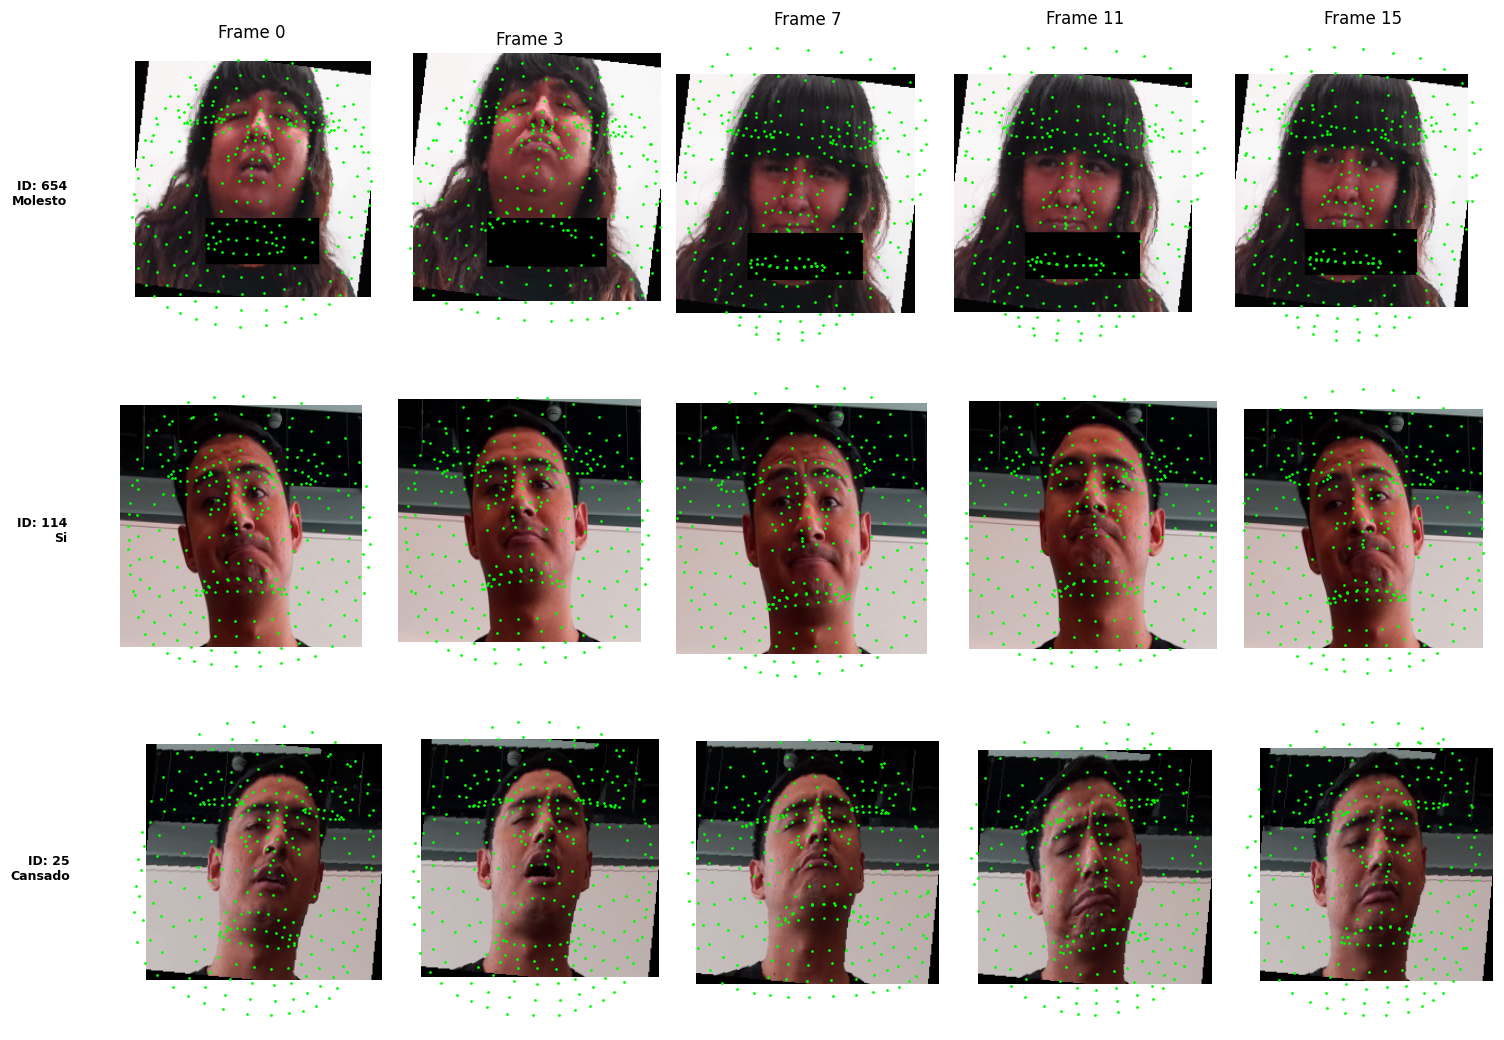

In [5]:
# ==========================================
# 3. PRUEBA DE CARGA VISUAL (CORREGIDA PARA DATASET OPTIMIZADO)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import random

def visualize_augmented_tensor(dataset, num_samples=3):
    # Validar tamaño
    if len(dataset) < num_samples: num_samples = len(dataset)
    indices = random.sample(range(len(dataset)), num_samples)
    
    # Stats para des-normalizar video
    mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
    std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)
    
    fig, axes = plt.subplots(num_samples, 5, figsize=(15, 3.5 * num_samples))
    if num_samples == 1: axes = np.array([axes])
    
    print(f"👁️ Visualizando Tensores Finales (Sincronizados)...")

    for row_idx, idx in enumerate(indices):
        # 1. Obtenemos lo que entra a la red
        x_rgb, x_lmk, y = dataset[idx]
        
        # 2. Des-normalizar Video
        vid = x_rgb.numpy().transpose(1, 2, 3, 0)
        vid = (vid * std) + mean
        vid = np.clip(vid, 0, 1)
        
        # 3. Des-normalizar Landmarks (Del Tensor)
        lmk_np = x_lmk.numpy().transpose(1, 2, 0) # (T, P, 2)
        
        frames_idx = np.linspace(0, vid.shape[0]-1, 5, dtype=int)
        
        for col_idx, t in enumerate(frames_idx):
            ax = axes[row_idx][col_idx]
            ax.imshow(vid[t])
            ax.axis('off')
            if row_idx == 0: ax.set_title(f"Frame {t}")
            
            # --- PLOTEAR LANDMARKS DEL TENSOR ---
            lmk = lmk_np[t]
            H, W = vid.shape[1:3]
            
            # Revertir normalización aproximada para visualización
            # x_pixel ≈ (x_norm * W) + (W / 2)
            xs = (lmk[:, 0] * W) + (W / 2)
            ys = (lmk[:, 1] * H) + (H / 2)
            
            # Filtrar solo los 180 puntos (Si x_lmk tiene 283)
            # Nota: Si ya estás usando la arquitectura que filtra, x_lmk ya tendrá 180 o 283.
            # Aquí solo ploteamos lo que venga.
            
            # Usar color verde brillante
            ax.scatter(xs, ys, s=4, c='#00FF00', marker='.')
        
        # --- FIX: OBTENER METADATOS CORRECTAMENTE ---
        if hasattr(dataset, 'dataset_map'):
            # Estamos en el Dataset Optimizado (Filtrado)
            meta = dataset.dataset_map[idx][1]
        else:
            # Estamos en el Dataset Antiguo
            meta = dataset.keys[idx]

        class_name = meta['class']
        # En el dataset optimizado, 'augment' siempre será 'rgb' en los metadatos,
        # pero la aumentación real ocurre al vuelo (es invisible aquí, pero visible en la imagen).
        info = f"ID: {idx}\n{class_name}"
        
        axes[row_idx][0].text(-0.2, 0.5, info, transform=axes[row_idx][0].transAxes, 
                              va='center', ha='right', fontsize=9, weight='bold')

    plt.tight_layout()
    plt.show()

# Ejecutar
visualize_augmented_tensor(train_ds, num_samples=3)

Arquitecturas: S2D-ViT + Multi-Scale ST-GCN

In [6]:
# ==========================================
# ARQUITECTURA COMPLETA S2D-GCN (Corregida & Unificada)
# ==========================================
import torch
import torch.nn as nn
import torchvision
import numpy as np
import os

# --- 1. DEFINICIÓN DE INDICES SELECCIONADOS (180 Puntos) ---
ranges = [
    (0, 35), (53, 87), (88, 124), (131, 164), # Contorno, Ojos, Nariz
    (220, 239), (241, 249), (251, 259)        # Boca
]
SELECTED_INDICES = []
for start, end in ranges:
    SELECTED_INDICES.extend(list(range(start, end + 1)))
SELECTED_INDICES = torch.tensor(SELECTED_INDICES, dtype=torch.long)
NUM_SELECTED_NODES = len(SELECTED_INDICES)

# --- 2. BACKBONE VISUAL (S2D ViT - FROZEN) ---
class TemporalModelingAdapter(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.alpha = nn.Parameter(torch.zeros(1)) 
    def forward(self, x, num_frames):
        BT, N, C = x.shape
        B = BT // num_frames
        x_t = x.view(B, num_frames, N, C).permute(0, 2, 1, 3).reshape(B*N, num_frames, C)
        out, _ = self.attn(self.norm(x_t), self.norm(x_t), self.norm(x_t))
        out = x_t + self.alpha * out
        return out.reshape(B, N, num_frames, C).permute(0, 2, 1, 3).reshape(BT, N, C)

class S2D_ViT_Backbone(nn.Module):
    def __init__(self, num_frames=16, weights_path="vit_b_16.pth"):
        super().__init__()
        print(f"🛠️ Inicializando ViT-B/16 Frozen...")
        self.vit = torchvision.models.vit_b_16(weights=None)
        
        if os.path.exists(weights_path):
            self.vit.load_state_dict(torch.load(weights_path))
            print("✅ Pesos ViT cargados.")
        
        # CONGELAR PESOS ESPACIALES
        for param in self.vit.parameters():
            param.requires_grad = False
            
        self.temporal_adapters = nn.ModuleList([
            TemporalModelingAdapter(768, dropout=0.2) for _ in range(len(self.vit.encoder.layers))
        ])

    def forward(self, x):
        B, C, T, H, W = x.shape
        x = x.permute(0, 2, 1, 3, 4).contiguous().view(B * T, C, H, W)
        x = self.vit.conv_proj(x)
        x = x.flatten(2).transpose(1, 2)
        cls_token = self.vit.class_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls_token, x], dim=1)
        x = x + self.vit.encoder.pos_embedding
        
        for i, layer in enumerate(self.vit.encoder.layers):
            x = layer(x)
            x = self.temporal_adapters[i](x, num_frames=T)
            
        x = self.vit.encoder.ln(x)
        return x[:, 0].view(B, T, -1)

# --- 3. BACKBONE GEOMÉTRICO (Multi-Scale ST-GCN Filtrado) ---
def create_adjacency_matrix_sparse(num_nodes):
    A = np.eye(num_nodes, dtype=np.float32)
    for i in range(num_nodes):
        for j in range(i+1, min(i+3, num_nodes)): 
             A[i, j] = 1.0
             A[j, i] = 1.0
    D = np.sum(A, axis=1) + 1e-6
    D_hat = np.diag(D ** -0.5)
    return torch.from_numpy(np.dot(np.dot(D_hat, A), D_hat))

class GraphConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, adjacency_matrix):
        super().__init__()
        self.A = nn.Parameter(adjacency_matrix, requires_grad=True) 
        self.W = nn.Linear(in_channels, out_channels)
        self.act = nn.ReLU()
    def forward(self, x):
        B, T, P, C = x.shape
        x_flat = x.reshape(B*T, P, C) 
        out = torch.matmul(self.A, x_flat) 
        out = self.W(out)                  
        return self.act(out.reshape(B, T, P, -1))

class TemporalConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2)
        self.bn = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    def forward(self, x):
        B, T, P, C = x.shape
        x = x.permute(0, 2, 3, 1).reshape(B*P, C, T)
        x = self.dropout(self.relu(self.bn(self.conv(x))))
        return x.view(B, P, -1, T).permute(0, 3, 1, 2)

class MultiScaleSTGCN(nn.Module):
    # CORRECCIÓN: Aceptamos 'num_nodes' aunque no lo usemos, para compatibilidad
    def __init__(self, in_channels=2, hidden_dim=64, num_nodes=283):
        super().__init__()
        self.register_buffer('point_mask', SELECTED_INDICES)
        
        A_init = create_adjacency_matrix_sparse(NUM_SELECTED_NODES)
        
        self.gcn1 = GraphConvolution(in_channels, hidden_dim, A_init)
        self.tcn1 = TemporalConvolution(hidden_dim, hidden_dim)
        self.gcn2 = GraphConvolution(hidden_dim, hidden_dim*2, A_init)
        self.tcn2 = TemporalConvolution(hidden_dim*2, hidden_dim*2)
        self.gcn3 = GraphConvolution(hidden_dim*2, hidden_dim*2, A_init)
        self.tcn3 = TemporalConvolution(hidden_dim*2, hidden_dim*2)
        self.out_dim = hidden_dim*2

    def forward(self, x):
        # x: (B, C, T, 283) -> Filtrar -> (B, C, T, 180)
        x = torch.index_select(x, dim=3, index=self.point_mask)
        x = x.permute(0, 2, 3, 1) # (B, T, 180, C)
        
        x = self.tcn1(self.gcn1(x))
        x = self.tcn2(self.gcn2(x))
        x = self.tcn3(self.gcn3(x))
        return torch.mean(x, dim=2) # Global Pooling

# --- 4. MODELO FINAL (Fusión) ---
class DFER_Hybrid_Model(nn.Module):
    def __init__(self, num_classes, num_frames=16):
        super().__init__()
        # Backbones
        self.visual_backbone = S2D_ViT_Backbone(num_frames=num_frames, weights_path="vit_b_16.pth")
        self.geo_backbone = MultiScaleSTGCN(in_channels=2, hidden_dim=64, num_nodes=283)
        
        # Fusión
        self.proj_v = nn.Linear(768, 256)
        self.proj_g = nn.Linear(128, 256)
        self.cma_attn = nn.MultiheadAttention(256, 4, batch_first=True)
        self.cma_norm = nn.LayerNorm(256)
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        
        # Clasificador (Dropout Aumentado 0.5)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x_rgb, x_lmk):
        v = self.proj_v(self.visual_backbone(x_rgb)) 
        g = self.proj_g(self.geo_backbone(x_lmk))
        
        # Cross Attention (Geo queries Visual)
        attn, _ = self.cma_attn(query=g, key=v, value=v)
        fused = self.cma_norm(g + attn)
        
        feat = self.temporal_pool(fused.transpose(1, 2)).flatten(1)
        return self.classifier(feat)

print("✅ Arquitectura S2D-GCN (Frozen + Filtered) definida correctamente.")

✅ Arquitectura S2D-GCN (Frozen + Filtered) definida correctamente.


Entrenamiento

In [7]:
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# ==========================================
# 7. LOOP DE ENTRENAMIENTO Y VALIDACIÓN
# ==========================================

def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    loop = tqdm(loader, desc="Training", leave=False)
    for batch in loop:
        x_rgb, x_lmk, y = batch
        x_rgb, x_lmk, y = x_rgb.to(DEVICE), x_lmk.to(DEVICE), y.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Mixed Precision Training
        with torch.cuda.amp.autocast():
            logits = model(x_rgb, x_lmk)
            loss = criterion(logits, y)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        
        # Métricas
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        
        loop.set_postfix(loss=loss.item())
        
    avg_loss = total_loss / len(loader)
    avg_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, avg_f1

def validate(model, loader, criterion, class_names):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validating", leave=False):
            x_rgb, x_lmk, y = batch
            x_rgb, x_lmk, y = x_rgb.to(DEVICE), x_lmk.to(DEVICE), y.to(DEVICE)
            
            logits = model(x_rgb, x_lmk)
            loss = criterion(logits, y)
            
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
    avg_loss = total_loss / len(loader)
    avg_f1 = f1_score(all_labels, all_preds, average='macro')
    
    # --- ANÁLISIS POR CLASE ---
    # output_dict=True devuelve un diccionario para procesar
    report = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
    
    # Filtrar solo las claves numéricas (clases) y mapear a nombres reales
    class_perf = []
    for k, v in report.items():
        if k.isdigit():
            idx = int(k)
            name = class_names[idx] if idx < len(class_names) else f"Class {k}"
            class_perf.append((name, v['f1-score']))
    
    # Ordenar por F1 Score
    sorted_perf = sorted(class_perf, key=lambda x: x[1], reverse=True)
    
    print(f"\n📊 Reporte Validación (F1 Macro: {avg_f1:.4f})")
    print(f"{'--- Top 3 Clases ---':<30} | {'--- Peores 3 Clases ---':<30}")
    
    # Imprimir columnas
    top_3 = sorted_perf[:3]
    bot_3 = sorted_perf[-3:]
    
    for i in range(3):
        t_name, t_score = top_3[i] if i < len(top_3) else ("", 0.0)
        b_name, b_score = bot_3[len(bot_3)-1-i] if i < len(bot_3) else ("", 0.0) # Invertir para mostrar el peor de todos al final
        print(f"{t_name[:20]:<20} {t_score:.4f}   |   {b_name[:20]:<20} {b_score:.4f}")
    
    return avg_loss, avg_f1, all_labels, all_preds

In [8]:
# ==========================================
# 8. EJECUCIÓN PRINCIPAL (Con Focal Loss)
# ==========================================
class FocalLoss(torch.nn.Module):
    def __init__(self, gamma=2.0, alpha=1.0, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.ce = torch.nn.CrossEntropyLoss(label_smoothing=label_smoothing, reduction='none')

    def forward(self, inputs, targets):
        log_pt = -self.ce(inputs, targets)
        pt = torch.exp(log_pt)
        loss = self.alpha * (1 - pt) ** self.gamma * self.ce(inputs, targets)
        return loss.mean()

# 1. Instanciar
print("🚀 Reiniciando con Aumentación Dinámica y Focal Loss...")
model = DFER_Hybrid_Model(num_classes=len(train_ds.class_names), num_frames=NUM_FRAMES).to(DEVICE)

# 2. Usamos Focal Loss en lugar de CE normal
criterion = FocalLoss(gamma=2.0, label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
scaler = torch.cuda.amp.GradScaler()

# 3. Resetear historial
best_f1 = 0.0
patience_counter = 0
history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}
model_save_path = os.path.join(OUTDIR, "best_s2d_gcn_dynamic.pth") # Nombre nuevo

# --- ENTRENAR ---
for epoch in range(EPOCHS):
    print(f"\n{'='*20} Epoch {epoch+1}/{EPOCHS} {'='*20}")
    t_loss, t_f1 = train_epoch(model, train_loader, criterion, optimizer, scaler)
    v_loss, v_f1, _, _ = validate(model, val_loader, criterion, train_ds.class_names)
    
    history['train_loss'].append(t_loss)
    history['val_f1'].append(v_f1)
    
    scheduler.step(v_f1)
    print(f"\n📉 Train Loss: {t_loss:.4f} | 📈 Train F1: {t_f1:.4f}")
    print(f"📉 Val Loss:   {v_loss:.4f} | 📈 Val F1:   {v_f1:.4f}")
    
    if v_f1 > best_f1:
        best_f1 = v_f1
        torch.save(model.state_dict(), model_save_path)
        print(f"⭐ ¡Récord! (F1: {best_f1:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("🛑 Early Stopping.")
            break

🚀 Reiniciando con Aumentación Dinámica y Focal Loss...
🛠️ Inicializando ViT-B/16 Frozen...
✅ Pesos ViT cargados.

==================== Epoch 1/40 ====================



📊 Reporte Validación (F1 Macro: 0.0601)
--- Top 3 Clases ---           | --- Peores 3 Clases ---       
Ladron               0.2424   |   Triste               0.0000
No                   0.2222   |   Si                   0.0000
Sorpresa             0.2000   |   No sé                0.0000

📉 Train Loss: 2.3616 | 📈 Train F1: 0.0822
📉 Val Loss:   2.2395 | 📈 Val F1:   0.0601
⭐ ¡Récord! (F1: 0.0601)

==================== Epoch 2/40 ====================



📊 Reporte Validación (F1 Macro: 0.0861)
--- Top 3 Clases ---           | --- Peores 3 Clases ---       
Sorpresa             0.6364   |   Triste               0.0000
No                   0.2353   |   Si                   0.0000
Molesto              0.2105   |   No sé                0.0000

📉 Train Loss: 2.2706 | 📈 Train F1: 0.0935
📉 Val Loss:   2.1912 | 📈 Val F1:   0.0861
⭐ ¡Récord! (F1: 0.0861)

==================== Epoch 3/40 ====================



📊 Reporte Validación (F1 Macro: 0.2323)
--- Top 3 Clases ---           | --- Peores 3 Clases ---       
Sorpresa             0.8889   |   Triste               0.0000
Feliz                0.6364   |   Si                   0.0000
No                   0.5000   |   No sé                0.0000

📉 Train Loss: 2.1309 | 📈 Train F1: 0.1756
📉 Val Loss:   2.0376 | 📈 Val F1:   0.2323
⭐ ¡Récord! (F1: 0.2323)

==================== Epoch 4/40 ====================



📊 Reporte Validación (F1 Macro: 0.2615)
--- Top 3 Clases ---           | --- Peores 3 Clases ---       
No                   0.7143   |   Triste               0.0000
Sorpresa             0.6957   |   Si                   0.0000
Feliz                0.5660   |   Ladron               0.0000

📉 Train Loss: 1.7668 | 📈 Train F1: 0.3445
📉 Val Loss:   1.7894 | 📈 Val F1:   0.2615
⭐ ¡Récord! (F1: 0.2615)

==================== Epoch 5/40 ====================


...


📊 Reporte Validación (F1 Macro: 0.5763)
--- Top 3 Clases ---           | --- Peores 3 Clases ---       
Feliz                0.8824   |   Disgusto             0.0000
Si                   0.8148   |   Ladron               0.2400
Llorar               0.8125   |   A ver                0.3030

📉 Train Loss: 0.4808 | 📈 Train F1: 0.9916
📉 Val Loss:   1.2514 | 📈 Val F1:   0.5763

==================== Epoch 26/40 ====================



📊 Reporte Validación (F1 Macro: 0.5713)
--- Top 3 Clases ---           | --- Peores 3 Clases ---       
Feliz                0.8571   |   Disgusto             0.0000
No                   0.8148   |   Ladron               0.2500
Llorar               0.8125   |   A ver                0.2941

📉 Train Loss: 0.4845 | 📈 Train F1: 0.9917
📉 Val Loss:   1.2816 | 📈 Val F1:   0.5713

==================== Epoch 27/40 ====================



📊 Reporte Validación (F1 Macro: 0.5700)
--- Top 3 Clases ---           | --- Peores 3 Clases ---       
Feliz                0.8571   |   Disgusto             0.0000
No                   0.8462   |   Ladron               0.1818
Si                   0.7857   |   A ver                0.2941

📉 Train Loss: 0.4787 | 📈 Train F1: 0.9905
📉 Val Loss:   1.2962 | 📈 Val F1:   0.5700

==================== Epoch 28/40 ====================



📊 Reporte Validación (F1 Macro: 0.5785)
--- Top 3 Clases ---           | --- Peores 3 Clases ---       
Feliz                0.8824   |   Disgusto             0.0000
No                   0.8148   |   A ver                0.2941
Llorar               0.8125   |   Ladron               0.3200

📉 Train Loss: 0.4615 | 📈 Train F1: 0.9940
📉 Val Loss:   1.2731 | 📈 Val F1:   0.5785

==================== Epoch 29/40 ====================



📊 Reporte Validación (F1 Macro: 0.5862)
--- Top 3 Clases ---           | --- Peores 3 Clases ---       
Feliz                0.8571   |   Disgusto             0.0000
No                   0.8148   |   Ladron               0.2609
Llorar               0.7879   |   A ver                0.2703

📉 Train Loss: 0.4680 | 📈 Train F1: 0.9952
📉 Val Loss:   1.2672 | 📈 Val F1:   0.5862
🛑 Early Stopping.



Generando curvas de aprendizaje...


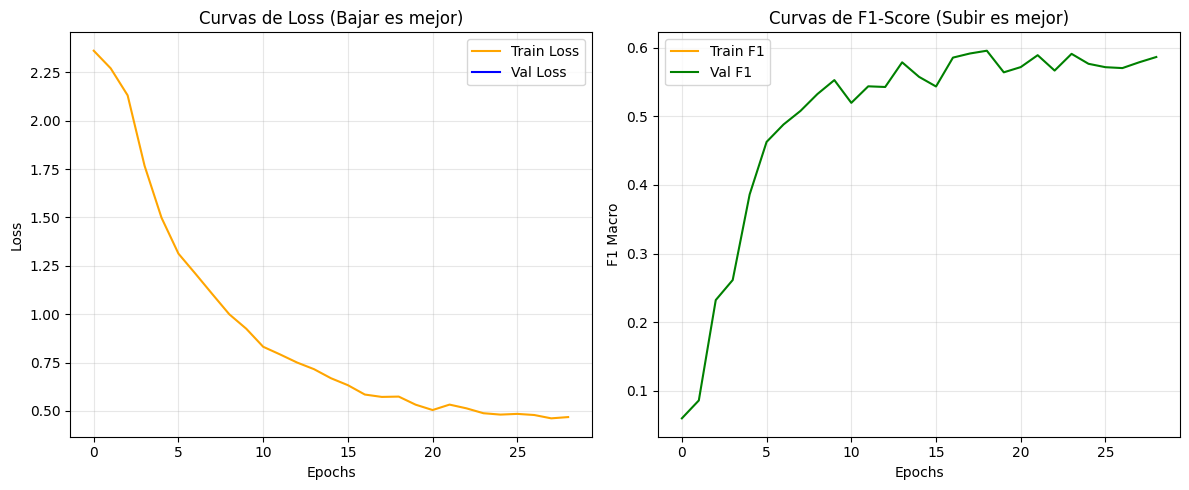

In [9]:
# --- GRÁFICAS FINALES ---
print("\nGenerando curvas de aprendizaje...")
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='orange')
plt.plot(history['val_loss'], label='Val Loss', color='blue')
plt.title('Curvas de Loss (Bajar es mejor)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# F1 Score
plt.subplot(1, 2, 2)
plt.plot(history['train_f1'], label='Train F1', color='orange')
plt.plot(history['val_f1'], label='Val F1', color='green')
plt.title('Curvas de F1-Score (Subir es mejor)')
plt.xlabel('Epochs')
plt.ylabel('F1 Macro')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Evaluacion en test


🔍 Evaluando el MEJOR modelo en el Test Set...
✅ Pesos cargados exitosamente.



📊 Reporte Validación (F1 Macro: 0.4792)
--- Top 3 Clases ---           | --- Peores 3 Clases ---       
Sorpresa             0.8462   |   Llorar               0.0000
Si                   0.7692   |   Ladron               0.1053
No                   0.7200   |   Disgusto             0.2647

🏆 TEST F1 MACRO FINAL: 0.4792

--- Reporte Detallado ---
              precision    recall  f1-score   support

       A ver       0.29      0.33      0.31        15
    Aburrido       0.31      0.31      0.31        16
     Cansado       0.77      0.62      0.69        16
    Disgusto       0.17      0.64      0.26        14
       Feliz       0.75      0.60      0.67        15
   Huele mal       0.44      0.27      0.33        15
      Ladron       0.25      0.07      0.11        15
      Llorar       0.00      0.00      0.00        15
     Molesto       0.57      0.86      0.69        14
          No       0.90      0.60      0.72        15
       No sé       0.25      0.40      0.31        15
  

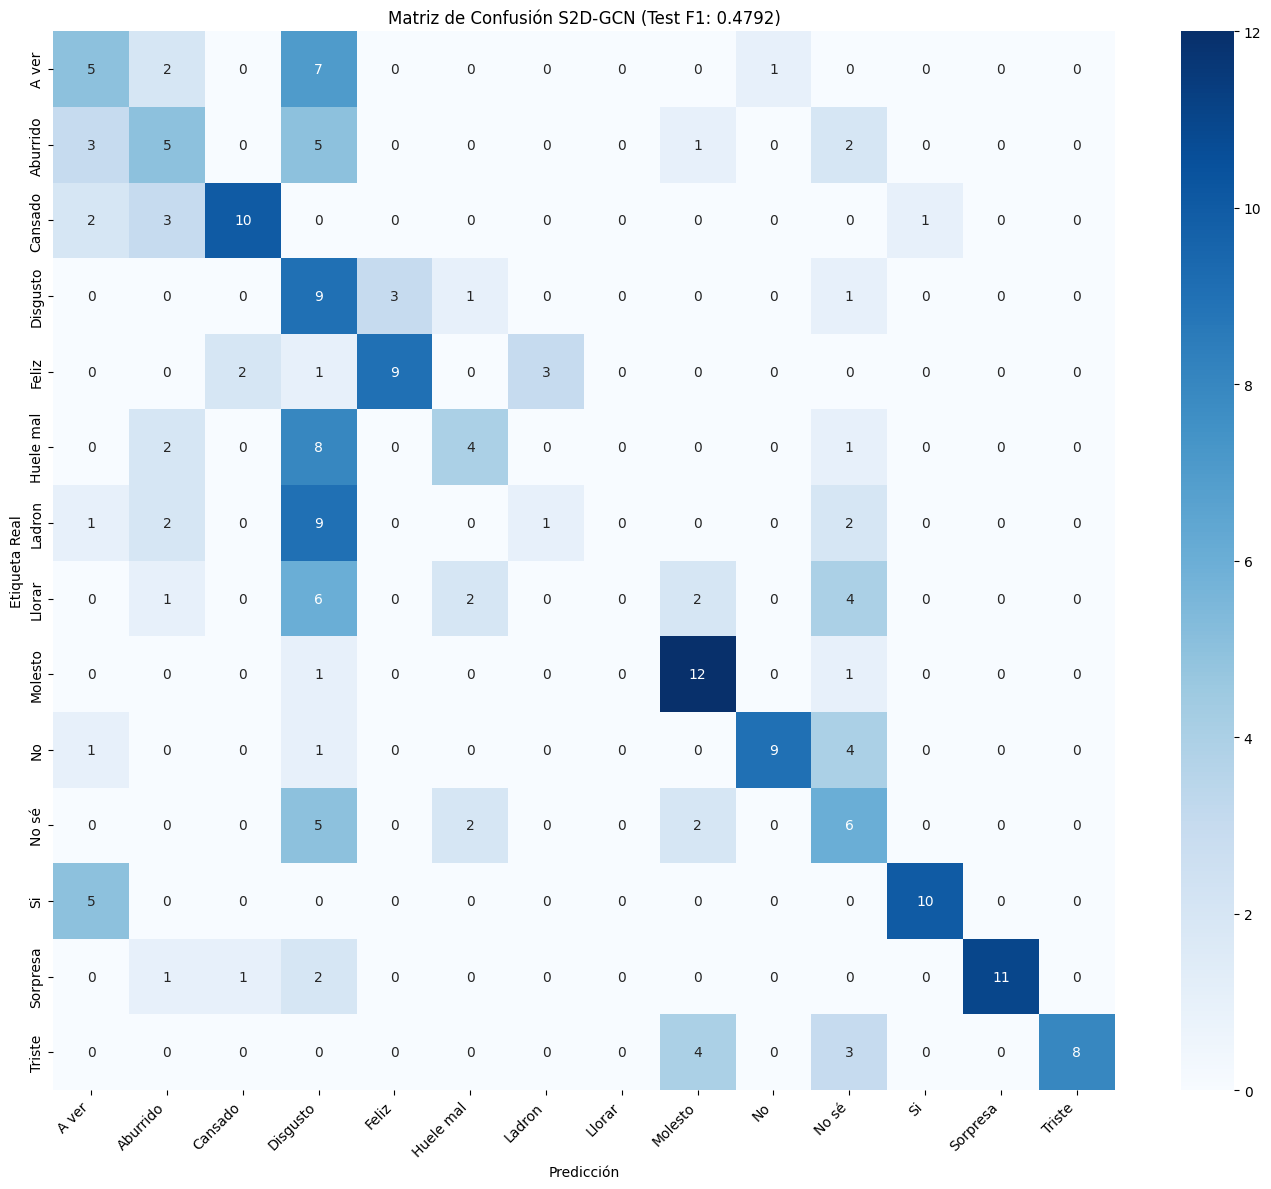

In [10]:
print("\n🔍 Evaluando el MEJOR modelo en el Test Set...")

# 1. Cargar mejores pesos
if os.path.exists(model_save_path):
    model.load_state_dict(torch.load(model_save_path))
    print("✅ Pesos cargados exitosamente.")
else:
    print("⚠️ No se encontró archivo de pesos, usando estado actual (riesgo de overfitting).")

# 2. Ejecutar validación en Test
test_loss, test_f1, y_true, y_pred = validate(model, test_loader, criterion, train_ds.class_names)

print(f"\n🏆 TEST F1 MACRO FINAL: {test_f1:.4f}")

# 3. Reporte de Clasificación Completo
print("\n--- Reporte Detallado ---")
print(classification_report(y_true, y_pred, target_names=train_ds.class_names, zero_division=0))

# 4. Matriz de Confusión Visual
plt.figure(figsize=(14, 12))
cm = confusion_matrix(y_true, y_pred)

# Normalizar matriz para ver porcentajes (opcional, ayuda si hay desbalance)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=train_ds.class_names, 
            yticklabels=train_ds.class_names)

plt.title(f'Matriz de Confusión S2D-GCN (Test F1: {test_f1:.4f})')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()